# Executive Summary

*This section provides an overview to the project.*
*It should briefly touch on the motivation, data question, data to be used, along with any known assumptions and challenges.*

Cancer remains one of the leading causes of death worldwide and represents a major burden on healthcare systems due to high treatment costs and long-term care needs. This project aims to explore the relationship between cancer incidence, mortality, and healthcare costs across different cancer types, demographic groups, and geographic regions within the United States. The motivation for this project comes from an interest in understanding how data-driven analysis can support healthcare decision-making and identify patterns related to disease severity and economic impact.

The project will combine publicly available healthcare datasets from government and research organizations such as the National Cancer Institute, Centers for Disease Control and Prevention, and Centers for Medicare & Medicaid Services. Data cleaning, integration, database management, exploratory analysis, visualization, statistical analysis, and machine learning will be performed using Python, SQL, and visualization tools such as R/Shiny or Tableau.

This project explores how cancer incidence and mortality patterns differ across cancer types and demographic groups within the United States. Particular attention is given to understanding whether cancers with high incidence are also associated with high mortality burden, and what these differences may suggest about disease severity, early detection challenges, treatment effectiveness, and healthcare outcomes.

Although significant progress has been made in cancer treatment through advances in personalized medicine, targeted therapies, and biomedical research, early cancer diagnosis remains a major challenge for many cancer types. This project seeks to better understand how differences in incidence and mortality patterns may reflect broader public health challenges related to early detection, disease severity, and healthcare outcomes.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json


# CDC Cancer Dataset Acquisition and File Selection

After exploring the SEER*Explorer platform from the National Cancer Institute (NCI) to better understand cancer incidence and mortality statistics, additional downloadable datasets were obtained from the Centers for Disease Control and Prevention (CDC) United States Cancer Statistics (USCS) database. The CDC datasets provide structured cancer incidence and mortality data suitable for exploratory analysis, visualization, SQL database integration, and machine learning workflows.

The CDC dataset package was downloaded as a compressed ZIP archive containing multiple text files organized for different types of public health analyses. These files included datasets grouped by:
- Cancer site/type
- Age group
- Geographic area
- County-level statistics
- Childhood cancer classifications
- Specialized cancer categories

Initial inspection of the extracted files showed several datasets, including:
- `BYSITE.TXT`
- `BYAGE.TXT`
- `BYAREA.TXT`
- `BYAREA_COUNTY.TXT`
- `CHILDBYSITE.TXT`
- `ICCCBYSITE.TXT`
- `USCS_ascii_input_program_2025.sas`
- `ICCCBYAGE_ADJ`

To identify the most appropriate dataset for the capstone project, the structure and variables of each file were evaluated based on the project objectives. The file `BYSITE.TXT` was selected as the primary dataset because it directly contains variables relevant to the proposed research questions, including:
- Cancer type (`SITE`)
- Incidence and mortality classifications (`EVENT_TYPE`)
- Demographic variables (`SEX`, `RACE`)
- Yearly observations (`YEAR`)
- Age-adjusted cancer rates (`AGE_ADJUSTED_RATE`)
- Case counts (`COUNT`)
- Population estimates (`POPULATION`)

The dataset spans multiple years (1999–2023) and includes both cancer incidence and mortality statistics across multiple cancer types and demographic groups within the United States. This structure makes the dataset highly suitable for:
- Exploratory data analysis
- Statistical analysis
- Trend analysis
- Demographic comparisons
- Data visualization
- SQL database integration
- Potential machine learning applications

The dataset was loaded into Python using the pandas library for initial inspection and analysis.

In [2]:
# Load CDC cancer dataset
cancer_cdc_df = pd.read_csv(
    "../data/BYSITE.TXT",
    sep="|"
)

In [3]:
cancer_cdc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68945 entries, 0 to 68944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   YEAR                   68945 non-null  object
 1   RACE                   68945 non-null  object
 2   SEX                    68945 non-null  object
 3   SITE                   68945 non-null  object
 4   EVENT_TYPE             68945 non-null  object
 5   AGE_ADJUSTED_CI_LOWER  68945 non-null  object
 6   AGE_ADJUSTED_CI_UPPER  68945 non-null  object
 7   AGE_ADJUSTED_RATE      68945 non-null  object
 8   COUNT                  68945 non-null  object
 9   POPULATION             68945 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 5.3+ MB


In [109]:
# Check CDC data structure
print(cancer_cdc_df.shape)

cancer_cdc_df.head()

(68945, 10)


,YEAR,RACE,SEX,SITE,EVENT_TYPE,AGE_ADJUSTED_CI_LOWER,AGE_ADJUSTED_CI_UPPER,AGE_ADJUSTED_RATE,COUNT,POPULATION
0,1999,All Races,Female,Acute Lymphocytic,Incidence,1.1,1.2,1.2,1652,140394214
1,1999,All Races,Female,Acute Lymphocytic,Mortality,0.4,0.4,0.4,582,142237295
2,2000,All Races,Female,Acute Lymphocytic,Incidence,1.2,1.3,1.3,1788,141865770
3,2000,All Races,Female,Acute Lymphocytic,Mortality,0.4,0.4,0.4,591,143719004
4,2001,All Races,Female,Acute Lymphocytic,Incidence,1.2,1.4,1.3,1837,143603977


### Initial Dataset Structure Inspection

The CDC cancer dataset contains 68,945 observations and 10 variables related to cancer incidence and mortality statistics across multiple demographic groups and years in the United States.

Initial inspection of the dataset structure using the `info()` function revealed that most variables were loaded as object data types, including several variables that represent numeric measurements such as:
- `AGE_ADJUSTED_RATE`
- `COUNT`
- `AGE_ADJUSTED_CI_LOWER`
- `AGE_ADJUSTED_CI_UPPER`

This suggests that some columns may contain non-numeric characters, suppressed values, or formatting inconsistencies that require additional cleaning before statistical analysis and visualization can be performed.

The `POPULATION` column was correctly identified as an integer variable during import.

In [4]:
# Check unique values in AGE_ADJUSTED_RATE
cancer_cdc_df["AGE_ADJUSTED_RATE"].unique()[:20]

array(['1.2', '0.4', '1.3', '1.4', '1.5', '0.3', '1.6', '3.1', '2.1',
       '3.2', '2.2', '3.0', '3.5', '3.6', '3.7', '2.3', '2.0', '420.5',
       '167.2', '421.3'], dtype=object)

### Investigating Numeric Variables Stored as Object Types

Although several columns represent numeric measurements, the initial dataset inspection showed that these variables were imported as object data types. Initial inspection of the `AGE_ADJUSTED_RATE` column revealed that many values appear numeric, suggesting that a small number of non-numeric or suppressed values may be causing the column to be interpreted as an object type.

Further inspection is required to identify special symbols, missing values, or formatting inconsistencies before converting these variables to numeric data types.

In [5]:
# Identify non-numeric values in AGE_ADJUSTED_RATE

cancer_cdc_df[
    pd.to_numeric(
        cancer_cdc_df["AGE_ADJUSTED_RATE"],
        errors="coerce"
    ).isna()
]["AGE_ADJUSTED_RATE"].unique()

array(['~', '.'], dtype=object)

### Investigating Object Data Types in Numeric Variables

Initial inspection of the dataset using the `info()` function showed that several variables expected to contain numeric values were imported as `object` data types. To better understand the issue, the `AGE_ADJUSTED_RATE` variable was selected for further inspection.

Although many values in the column appeared numeric, the variable was still stored as an object type. This suggested that some rows may contain non-numeric placeholder values or formatting inconsistencies.

To investigate further, the `pd.to_numeric()` function was used with `errors="coerce"` to identify values that could not be converted into numeric format. This process revealed non-numeric placeholder symbols such as:
- `~`
- `.`

These symbols are commonly used in public healthcare datasets to represent suppressed or missing values and explain why the column was initially imported as an object data type.

### Convert Numeric Columns Stored as Objects

Several columns that represent numeric values were imported as object data types because they contain non-numeric placeholder symbols such as `~` and `.`. To clean these variables consistently, a reusable function was created to replace placeholder values with `NaN` and convert selected columns to numeric data types.

In [6]:
# Define numeric columns to clean and convert

numeric_cols = [
    "AGE_ADJUSTED_CI_LOWER",
    "AGE_ADJUSTED_CI_UPPER",
    "AGE_ADJUSTED_RATE",
    "COUNT"
]

# Create a function to clean and convert numeric columns

def clean_numeric_columns(df, columns):
    """
    Replace placeholder values with NaN and convert selected columns to numeric.
    """
    df = df.copy()
    
    for col in columns:
        df[col] = df[col].replace(["~", "."], np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    return df

cancer_cdc_df_cleaned = clean_numeric_columns(cancer_cdc_df, numeric_cols)

In [7]:
cancer_cdc_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68945 entries, 0 to 68944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   YEAR                   68945 non-null  object 
 1   RACE                   68945 non-null  object 
 2   SEX                    68945 non-null  object 
 3   SITE                   68945 non-null  object 
 4   EVENT_TYPE             68945 non-null  object 
 5   AGE_ADJUSTED_CI_LOWER  58584 non-null  float64
 6   AGE_ADJUSTED_CI_UPPER  58584 non-null  float64
 7   AGE_ADJUSTED_RATE      58584 non-null  float64
 8   COUNT                  58584 non-null  float64
 9   POPULATION             68945 non-null  int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 5.3+ MB


In [8]:
sorted(cancer_cdc_df_cleaned["YEAR"].unique())

['1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2018-2022',
 '2019',
 '2019-2023',
 '2020',
 '2021',
 '2022',
 '2023']

### Inspecting Missing Values

After replacing placeholder symbols with `NaN` and converting selected variables to numeric data types, the next step is to inspect the dataset for missing values.

Understanding the distribution of missing values is important because missing data can affect:
- statistical analysis
- visualizations
- trend interpretation
- machine learning workflows

This step helps determine whether missing values are limited to specific variables or occur more broadly across the dataset.

In [9]:
cancer_cdc_df_cleaned.isna().sum()

YEAR                         0
RACE                         0
SEX                          0
SITE                         0
EVENT_TYPE                   0
AGE_ADJUSTED_CI_LOWER    10361
AGE_ADJUSTED_CI_UPPER    10361
AGE_ADJUSTED_RATE        10361
COUNT                    10361
POPULATION                   0
dtype: int64

# Exploring Cancer Event Types

The dataset contains an `EVENT_TYPE` variable that distinguishes between different types of cancer statistics reported in the dataset.

Inspecting this variable helps verify whether the dataset includes:
- cancer incidence rates
- cancer mortality rates

This step is important because the capstone project aims to compare patterns in both cancer incidence and mortality across cancer types and demographic groups.

In [10]:
# Display unique event types

cancer_cdc_df_cleaned["EVENT_TYPE"].unique()

array(['Incidence', 'Mortality'], dtype=object)

In [11]:
# Count incidence and mortality observations

cancer_cdc_df_cleaned["EVENT_TYPE"].value_counts()

EVENT_TYPE
Mortality    35045
Incidence    33900
Name: count, dtype: int64

### Exploring Event Types

Inspection of the `EVENT_TYPE` variable confirmed that the dataset contains both:
- cancer incidence observations
- cancer mortality observations

The dataset includes:
- 35,045 mortality records
- 33,900 incidence records

This is an important feature of the dataset because it allows direct comparison between cancer incidence and mortality trends across different cancer types, demographic groups, and years.

In [12]:
# Display all cancer site categories

sorted(cancer_cdc_df_cleaned["SITE"].unique())

['Acute Lymphocytic',
 'Acute Myeloid',
 'All Cancer Sites Combined',
 'All Sites (comparable to ICD-O-2)',
 'Anus, Anal Canal and Anorectum',
 'Bones and Joints',
 'Brain',
 'Brain and Other Nervous System',
 'Cervix',
 'Chronic Lymphocytic',
 'Chronic Myeloid',
 'Colon and Rectum',
 'Colon excluding Rectum',
 'Corpus',
 'Corpus and Uterus, NOS',
 'Cranial Nerves and Other Nervous System',
 'Digestive System',
 'Endocrine System',
 'Esophagus',
 'Eye and Orbit',
 'Female Breast',
 'Female Breast, <i>in situ</i>',
 'Female Genital System',
 'Floor of Mouth',
 'Gallbladder',
 'Gum and Other Mouth',
 'Hodgkin Lymphoma',
 'Hypopharynx',
 'Kaposi Sarcoma',
 'Kidney and Renal Pelvis',
 'Larynx',
 'Leukemias',
 'Lip',
 'Liver and Intrahepatic Bile Duct',
 'Lung and Bronchus',
 'Lymphomas',
 'Male Breast',
 'Male Genital System',
 'Male and Female Breast',
 'Male and Female Breast, <i>in situ</i>',
 'Melanomas of the Skin',
 'Mesothelioma',
 'Miscellaneous',
 'Myeloma',
 'Nasopharynx',
 'Non-

## Refining Cancer Site Categories for Analysis

Initial exploration of the `SITE` variable revealed that the dataset contains multiple levels of cancer classification, including:
- specific cancer types
- organ-system groupings
- combined summary categories
- broader disease classifications

Examples of broad grouped categories include:
- `All Cancer Sites Combined`
- `Digestive System`
- `Respiratory System`
- `Male Genital System`
- `Lymphomas`

These categories may overlap conceptually with more specific cancer types already present in the dataset. For example:
- `Digestive System` may include cancers such as colon, pancreas, liver, and stomach.
- `Respiratory System` may include lung and bronchus cancers.

Including both broad grouped categories and individual cancer types in the same ranking analysis could lead to:
- overlapping counts
- inflated interpretations
- difficulty comparing cancer-specific incidence and mortality burden

To improve analytical clarity and create more interpretable comparisons, broad grouped categories were removed from the dataset prior to calculating the top cancer incidence and mortality rankings.

In [13]:
# Broad grouped cancer categories to exclude

exclude_sites = [
    "All Cancer Sites Combined",
    "All Sites (comparable to ICD-O-2)",
    "Digestive System",
    "Respiratory System",
    "Male Genital System",
    "Female Genital System",
    "Urinary System",
    "Oral Cavity and Pharynx",
    "Brain and Other Nervous System",
    "Miscellaneous",
    "Leukemias",
    "Lymphomas"
]

# Remove broad grouped cancer categories

clean_cancer_cdc_df = cancer_cdc_df_cleaned[
    ~cancer_cdc_df_cleaned["SITE"].isin(exclude_sites)
]

In [131]:
clean_cancer_cdc_df

,YEAR,RACE,SEX,SITE,EVENT_TYPE,AGE_ADJUSTED_CI_LOWER,AGE_ADJUSTED_CI_UPPER,AGE_ADJUSTED_RATE,COUNT,POPULATION
11240,2018,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1224062
11241,2019,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1230918
11242,2019-2023,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,0.3,0.6,0.4,26.0,6137446
11243,2020,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1220598
11244,2021,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1224571
...,...,...,...,...,...,...,...,...,...,...
68394,2019-2023,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.9,8.0,7.9,52754.0,486984486
68395,2020,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.9,8.2,8.1,10430.0,97992536
68396,2021,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.9,8.2,8.1,10547.0,97570662
68397,2022,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.8,8.2,8.0,10688.0,97193663


In [14]:
# Display all cancer site categories

sorted(clean_cancer_cdc_df["SITE"].unique())

['Acute Lymphocytic',
 'Acute Myeloid',
 'Anus, Anal Canal and Anorectum',
 'Bones and Joints',
 'Brain',
 'Cervix',
 'Chronic Lymphocytic',
 'Chronic Myeloid',
 'Colon and Rectum',
 'Colon excluding Rectum',
 'Corpus',
 'Corpus and Uterus, NOS',
 'Cranial Nerves and Other Nervous System',
 'Endocrine System',
 'Esophagus',
 'Eye and Orbit',
 'Female Breast',
 'Female Breast, <i>in situ</i>',
 'Floor of Mouth',
 'Gallbladder',
 'Gum and Other Mouth',
 'Hodgkin Lymphoma',
 'Hypopharynx',
 'Kaposi Sarcoma',
 'Kidney and Renal Pelvis',
 'Larynx',
 'Lip',
 'Liver and Intrahepatic Bile Duct',
 'Lung and Bronchus',
 'Male Breast',
 'Male and Female Breast',
 'Male and Female Breast, <i>in situ</i>',
 'Melanomas of the Skin',
 'Mesothelioma',
 'Myeloma',
 'Nasopharynx',
 'Non-Hodgkin Lymphoma',
 'Nose, Nasal Cavity and Middle Ear',
 'Oropharynx',
 'Other Biliary',
 'Other Digestive Organs',
 'Other Endocrine including Thymus',
 'Other Female Genital Organs',
 'Other Leukemias',
 'Other Male G

### Exploring Cancer Site Categories

Initial inspection of the `SITE` variable revealed that the dataset contains multiple levels of cancer classification, including:
- specific cancer types
- leukemia and lymphoma subtypes
- organ-system groupings
- combined summary categories

Examples identified during the initial exploration included:
- `Acute Lymphocytic`
- `Brain`
- `Colon and Rectum`
- `Digestive System`
- `All Cancer Sites Combined`

Because several categories represented broad organ systems or combined summary classifications, some cancer categories overlapped conceptually with more specific cancer types already present in the dataset. For example:
- `Digestive System` may include cancers such as colon, pancreas, liver, and stomach.
- `Respiratory System` may include lung and bronchus cancers.

To improve analytical clarity and reduce overlapping interpretations, broad grouped categories were removed prior to conducting cancer-specific incidence and mortality comparisons. This refinement produced a cleaner subset of more interpretable cancer categories for exploratory analysis and visualization.

### Exploring Cancer Incidence and Mortality Patterns

After completing the initial data cleaning and cancer category refinement steps, the next phase of exploratory analysis focused on identifying patterns in cancer incidence and mortality across different cancer types.

This analysis aims to:
- identify cancers with the highest incidence burden
- identify cancers associated with the highest mortality burden
- compare incidence and mortality patterns across cancer types
- explore whether cancers with high incidence are always associated with high mortality
- support future visualizations, statistical analysis, and healthcare interpretation

Initial exploratory findings suggest that cancers with high incidence are not always associated with the highest mortality burden. These observations may reflect broader differences related to:
- disease severity
- early detection challenges
- cancer progression rates
- treatment effectiveness
- survival outcomes across cancer types

In [15]:
# Filter incidence records

cancer_incidence_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["EVENT_TYPE"] == "Incidence"
]

In [16]:
# Filter mortality records

cancer_mortality_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["EVENT_TYPE"] == "Mortality"
]

In [17]:
# Top 10 cancer types by incidence count

top_cancer_type_incidence = (
    cancer_incidence_df.groupby("SITE")["COUNT"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cancer_type_incidence

SITE
Female Breast                        27374806.0
Prostate                             25436190.0
Lung and Bronchus                    24993472.0
Colon and Rectum                     16937926.0
Male and Female Breast               13803280.0
Colon excluding Rectum               12113504.0
Skin excluding Basal and Squamous     9025734.0
Melanomas of the Skin                 8371106.0
Urinary Bladder                       8299030.0
Non-Hodgkin Lymphoma                  7730812.0
Name: COUNT, dtype: float64

In [18]:
# Top 10 cancer types by mortality count
top_cancer_type_mortality = (
    cancer_mortality_df.groupby("SITE")["COUNT"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cancer_type_mortality

SITE
Lung and Bronchus                   17778048.0
Colon and Rectum                     6372932.0
Colon excluding Rectum               5151090.0
Female Breast                        4980540.0
Pancreas                             4770080.0
Prostate                             3652150.0
Liver and Intrahepatic Bile Duct     2706059.0
Male and Female Breast               2516813.0
Non-Hodgkin Lymphoma                 2467980.0
Urinary Bladder                      1819715.0
Name: COUNT, dtype: float64

### Initial Incidence and Mortality Comparisons

Comparison of the top cancer incidence and mortality counts revealed important differences between cancer occurrence and cancer-related deaths across cancer types.

Cancers such as:
- Female Breast
- Prostate
- Lung and Bronchus
- Colon and Rectum

showed some of the highest overall incidence counts within the dataset.

In contrast, mortality analysis showed that:
- Lung and Bronchus
- Pancreas
- Liver and Intrahepatic Bile Duct
- Colon and Rectum

contributed disproportionately to cancer-related deaths.

These findings suggest that cancers with high incidence are not always associated with the highest mortality burden. For example:
- Prostate cancer showed very high incidence but comparatively lower mortality.
- Pancreatic cancer appeared among the leading causes of cancer mortality despite not appearing among the highest incidence cancers.

These early observations may reflect broader differences related to:
- disease severity
- cancer progression rates
- effectiveness of early detection
- treatment availability and effectiveness
- long-term survival outcomes

### Comparing Cancer Incidence and Mortality Burden

To directly compare cancer incidence and mortality patterns, the top cancer types were visualized using a grouped horizontal bar chart.

This comparison helps highlight:
- cancers with high incidence but comparatively lower mortality
- cancers with disproportionately high mortality burden
- potential differences related to disease severity, early detection, treatment effectiveness, and long-term survival outcomes

In [19]:
# Combine incidence and mortality counts into one dataframe

incidence_mortality_comparison_df = pd.DataFrame({
    "Incidence": top_cancer_type_incidence,
    "Mortality": top_cancer_type_mortality
}).fillna(0)

incidence_mortality_comparison_df

,Incidence,Mortality
SITE,,
Colon and Rectum,16937926.0,6372932.0
Colon excluding Rectum,12113504.0,5151090.0
Female Breast,27374806.0,4980540.0
Liver and Intrahepatic Bile Duct,0.0,2706059.0
Lung and Bronchus,24993472.0,17778048.0
Male and Female Breast,13803280.0,2516813.0
Melanomas of the Skin,8371106.0,0.0
Non-Hodgkin Lymphoma,7730812.0,2467980.0
Pancreas,0.0,4770080.0


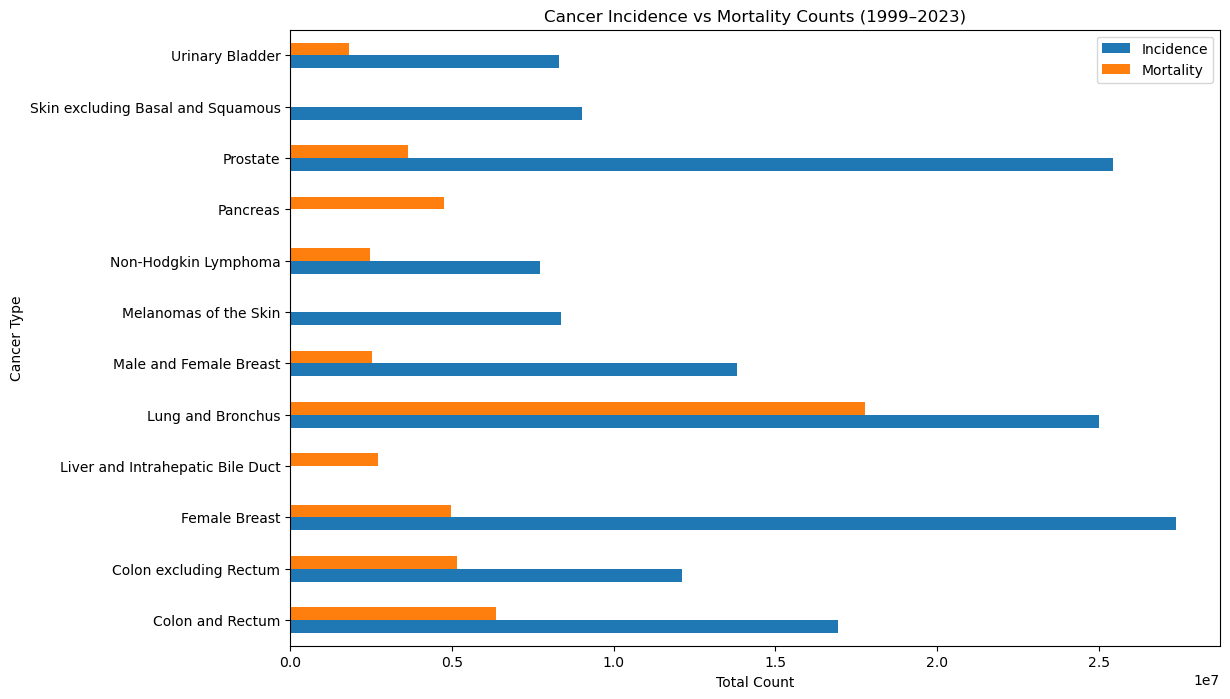

In [20]:
# Plot incidence vs mortality comparison

incidence_mortality_comparison_df.plot(
    kind="barh",
    figsize=(12, 8)
)

plt.xlabel("Total Count")
plt.ylabel("Cancer Type")
plt.title("Cancer Incidence vs Mortality Counts (1999–2023)")

plt.show()

### Interpreting Disproportionate Mortality Burden

Some cancers, such as pancreatic cancer, appeared among the leading causes of cancer mortality despite not appearing among the highest incidence cancer categories within the dataset.

This pattern may suggest broader challenges related to:
- early detection and diagnosis
- aggressive disease progression
- limited treatment effectiveness
- lower long-term survival rates

Because this analysis is based on population-level aggregate data, these observations should be interpreted as exploratory patterns and hypothesis-generating insights rather than direct causal conclusions.

### Exploring Demographic Categories

The dataset includes demographic variables that allow exploratory analysis across population groups. Understanding how cancer incidence and mortality vary across demographic categories may provide insight into:
- healthcare disparities
- population-level cancer burden
- differences in early detection and outcomes
- potential inequities in healthcare access

The first demographic variable explored was race and ethnicity.

In [21]:
# Display race and ethnicity categories

sorted(clean_cancer_cdc_df["RACE"].unique())

['All Races',
 'American Indian/Alaska Native, Non-Hispanic',
 'Asian, Non Hispanic',
 'Black, Non-Hispanic',
 'Hispanic',
 'Hispanic of any race',
 'Native Hawaiinn or other Pacific Islander, Non- Hispani',
 'Non-Hispanic American Indian/Alaska Native',
 'Non-Hispanic Asian/Pacific Islander',
 'Non-Hispanic Black',
 'Non-Hispanic White',
 'White, Non-Hispanic']

### Exploring Race and Ethnicity Categories

Inspection of the `RACE` variable revealed multiple race and ethnicity classifications within the dataset, including:
- broad racial groups
- Hispanic ethnicity categories
- non-Hispanic subgroup classifications

Initial exploration also identified inconsistencies and overlapping naming conventions across demographic categories. Examples include:
- `Black, Non-Hispanic`
- `Non-Hispanic Black`

and:
- `Asian, Non Hispanic`
- `Non-Hispanic Asian/Pacific Islander`

These observations highlight potential demographic standardization challenges that may require additional preprocessing before conducting detailed population-level comparisons.

Such inconsistencies are common in large public health datasets and reflect differences in reporting standards, classification systems, and aggregation methods across healthcare surveillance sources.

In [22]:

clean_cancer_cdc_df["RACE"].value_counts()

RACE
All Races                                                  9584
Non-Hispanic Black                                         8296
Non-Hispanic American Indian/Alaska Native                 8296
Hispanic of any race                                       8296
Non-Hispanic White                                         8296
Non-Hispanic Asian/Pacific Islander                        8296
American Indian/Alaska Native, Non-Hispanic                1288
Asian, Non Hispanic                                        1288
Black, Non-Hispanic                                        1288
Hispanic                                                   1288
Native Hawaiinn or other Pacific Islander, Non- Hispani    1288
White, Non-Hispanic                                        1288
Name: count, dtype: int64

### Standardizing Race and Ethnicity Categories

Exploration of the `RACE` variable revealed duplicated and inconsistently formatted demographic categories within the dataset. Several race and ethnicity groups appeared under multiple naming conventions.

Examples included:
- `Black, Non-Hispanic` and `Non-Hispanic Black`
- `White, Non-Hispanic` and `Non-Hispanic White`

These inconsistencies likely reflect differences in reporting standards or classification systems across public health data sources and reporting periods.

To improve analytical consistency and avoid fragmented demographic counts, duplicated race and ethnicity labels were standardized into unified category names prior to further demographic analysis.

In [23]:
# Standardize duplicated race and ethnicity categories

race_mapping = {
    "Black, Non-Hispanic": "Non-Hispanic Black",
    "White, Non-Hispanic": "Non-Hispanic White",
    "American Indian/Alaska Native, Non-Hispanic":
        "Non-Hispanic American Indian/Alaska Native",
    "Asian, Non Hispanic":
        "Non-Hispanic Asian/Pacific Islander",
    "Hispanic": "Hispanic of any race"
}

# Create a cleaned dataframe excluding broad grouped cancer categories

clean_cancer_cdc_df = clean_cancer_cdc_df[
    ~clean_cancer_cdc_df["SITE"].isin(exclude_sites)
].copy()

# Verify updated race categories

clean_cancer_cdc_df["RACE"].value_counts()

RACE
All Races                                                  9584
Non-Hispanic Black                                         8296
Non-Hispanic American Indian/Alaska Native                 8296
Hispanic of any race                                       8296
Non-Hispanic White                                         8296
Non-Hispanic Asian/Pacific Islander                        8296
American Indian/Alaska Native, Non-Hispanic                1288
Asian, Non Hispanic                                        1288
Black, Non-Hispanic                                        1288
Hispanic                                                   1288
Native Hawaiinn or other Pacific Islander, Non- Hispani    1288
White, Non-Hispanic                                        1288
Name: count, dtype: int64

In [24]:
# Apply race category standardization

clean_cancer_cdc_df["RACE"] = (
    clean_cancer_cdc_df["RACE"]
    .replace(race_mapping)
)

### Exploring Cancer Burden Across Race and Ethnicity Groups

After standardizing race and ethnicity categories, exploratory analysis focused on comparing cancer incidence and mortality burden across demographic groups.

Rather than counting dataset observations, this analysis aggregates actual cancer counts using the `COUNT` variable. This approach provides a more meaningful representation of population-level cancer burden across race and ethnicity categories.

The analysis aims to explore:
- demographic differences in cancer incidence
- demographic differences in cancer mortality
- potential public health disparities across population groups

In [25]:
# Aggregate cancer incidence counts by race

race_incidence = (
    clean_cancer_cdc_df[
        clean_cancer_cdc_df["EVENT_TYPE"] == "Incidence"
    ]
    .groupby("RACE")["COUNT"]
    .sum()
    .sort_values(ascending=False)
)

race_incidence

RACE
All Races                                     119915749.0
Non-Hispanic White                             92669729.0
Non-Hispanic Black                             12379198.0
Hispanic of any race                            9256307.0
Non-Hispanic Asian/Pacific Islander             3819067.0
Non-Hispanic American Indian/Alaska Native       642252.0
Name: COUNT, dtype: float64

In [26]:
# Aggregate cancer mortality counts by race

race_mortality = (
    clean_cancer_cdc_df[
        clean_cancer_cdc_df["EVENT_TYPE"] == "Mortality"
    ]
    .groupby("RACE")["COUNT"]
    .sum()
    .sort_values(ascending=False)
)

race_mortality

RACE
All Races                                                  37405438.0
Non-Hispanic White                                         29409966.0
Non-Hispanic Black                                          4390194.0
Hispanic of any race                                        2277186.0
Non-Hispanic Asian/Pacific Islander                          973897.0
Non-Hispanic American Indian/Alaska Native                   163193.0
Native Hawaiinn or other Pacific Islander, Non- Hispani       16962.0
Name: COUNT, dtype: float64

### Refining Demographic Comparisons

The `All Races` category represents a combined summary across all demographic groups rather than an independent population category. Including this category in demographic comparisons may dominate aggregated results and reduce interpretability across individual race and ethnicity groups.

To improve clarity and support more meaningful demographic comparisons, the `All Races` summary category was excluded from subsequent race and ethnicity analyses.

In [27]:
# Remove combined summary race category

race_incidence = race_incidence.drop("All Races")

race_mortality = race_mortality.drop("All Races")

In [28]:
race_mortality

RACE
Non-Hispanic White                                         29409966.0
Non-Hispanic Black                                          4390194.0
Hispanic of any race                                        2277186.0
Non-Hispanic Asian/Pacific Islander                          973897.0
Non-Hispanic American Indian/Alaska Native                   163193.0
Native Hawaiinn or other Pacific Islander, Non- Hispani       16962.0
Name: COUNT, dtype: float64

### Comparing Cancer Burden Across Race and Ethnicity Groups

Cancer incidence and mortality counts were compared across race and ethnicity groups to explore potential demographic differences in overall cancer burden.

This comparison helps:
- identify populations with higher cancer incidence burden
- identify populations with higher cancer mortality burden
- support exploratory investigation of demographic disparities in cancer outcomes

Because the `All Races` category represents a combined summary across all demographic groups, it was excluded from visualization to improve interpretability across individual population categories.

In [29]:
# Combine race incidence and mortality counts

race_comparison_df = pd.DataFrame({
    "Incidence": race_incidence,
    "Mortality": race_mortality
}).fillna(0)

race_comparison_df

,Incidence,Mortality
RACE,,
Hispanic of any race,9256307.0,2277186.0
"Native Hawaiinn or other Pacific Islander, Non- Hispani",0.0,16962.0
Non-Hispanic American Indian/Alaska Native,642252.0,163193.0
Non-Hispanic Asian/Pacific Islander,3819067.0,973897.0
Non-Hispanic Black,12379198.0,4390194.0
Non-Hispanic White,92669729.0,29409966.0


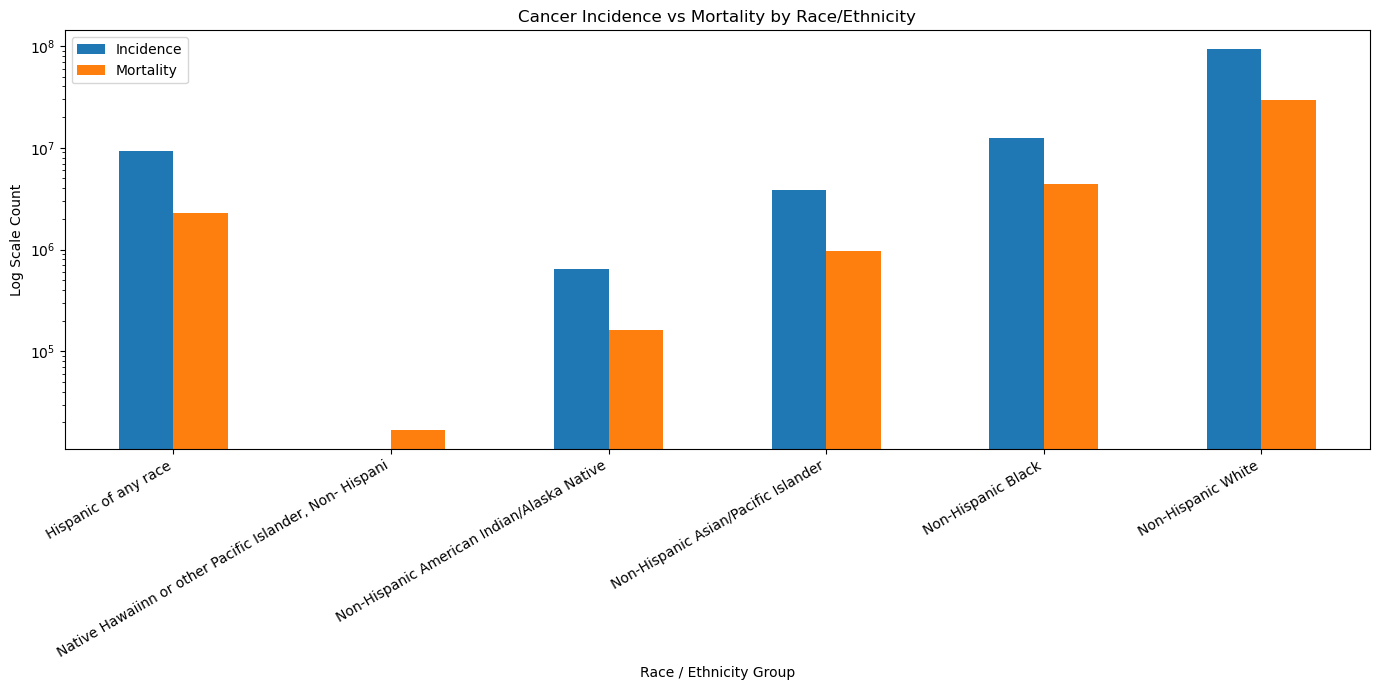

In [30]:
# Plot cancer incidence vs mortality by race

race_comparison_df.plot(
    kind="bar",
    figsize=(14, 7),
    logy=True
)

plt.ylabel("Log Scale Count")
plt.xlabel("Race / Ethnicity Group")
plt.title("Cancer Incidence vs Mortality by Race/Ethnicity")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

### Comparing Cancer Burden Across Race and Ethnicity Groups

Cancer incidence and mortality counts were compared across race and ethnicity groups to explore potential demographic differences in overall cancer burden.

Initial exploratory analysis showed noticeable differences in cancer incidence and mortality across population groups. These patterns may reflect broader public health factors related to:
- healthcare access
- early detection
- disease severity
- population size
- long-term cancer outcomes

To improve interpretability, the combined `All Races` summary category was excluded from demographic comparisons.

### Exploring Sex-Based Cancer Patterns

The dataset also includes sex-based demographic categories that allow comparison of cancer incidence and mortality patterns between male and female populations.

Exploring cancer burden across sex categories may help identify:
- differences in cancer incidence
- differences in cancer mortality
- sex-specific cancer patterns
- potential differences in long-term cancer outcomes

In [31]:
# Display sex categories

clean_cancer_cdc_df["SEX"].unique()

array(['Female', 'Male', 'Male and Female'], dtype=object)

In [32]:
# Aggregate cancer incidence counts by sex

sex_incidence = (
    clean_cancer_cdc_df[
        clean_cancer_cdc_df["EVENT_TYPE"] == "Incidence"
    ]
    .groupby("SEX")["COUNT"]
    .sum()
    .sort_values(ascending=False)
)

sex_incidence

SEX
Male and Female    126195423.0
Female              58102879.0
Male                54384000.0
Name: COUNT, dtype: float64

In [33]:
# Aggregate cancer mortality counts by sex

sex_mortality = (
    clean_cancer_cdc_df[
        clean_cancer_cdc_df["EVENT_TYPE"] == "Mortality"
    ]
    .groupby("SEX")["COUNT"]
    .sum()
    .sort_values(ascending=False)
)

sex_mortality

SEX
Male and Female    38569969.0
Male               18621327.0
Female             17445540.0
Name: COUNT, dtype: float64

In [34]:
# Remove combined sex category

sex_incidence = sex_incidence.drop("Male and Female")

sex_mortality = sex_mortality.drop("Male and Female")

In [35]:
# Combine incidence and mortality by sex

sex_comparison_df = pd.DataFrame({
    "Incidence": sex_incidence,
    "Mortality": sex_mortality
}).fillna(0)

sex_comparison_df

,Incidence,Mortality
SEX,,
Female,58102879.0,17445540.0
Male,54384000.0,18621327.0


### Comparing Cancer Burden Across Sex Categories

Cancer incidence and mortality counts were compared between male and female populations to explore potential differences in overall cancer burden and outcomes.

Initial exploratory analysis showed:
- slightly higher overall cancer incidence among females
- higher overall cancer mortality among males

### Visualizing Demographic Cancer Burden

Cancer incidence and mortality comparisons were visualized across demographic groups to support exploratory analysis of population-level cancer burden and potential healthcare disparities.

The visualizations help:
- compare incidence and mortality burden across demographic categories
- identify patterns associated with higher mortality burden
- support interpretation of potential differences in healthcare outcomes and disease burden

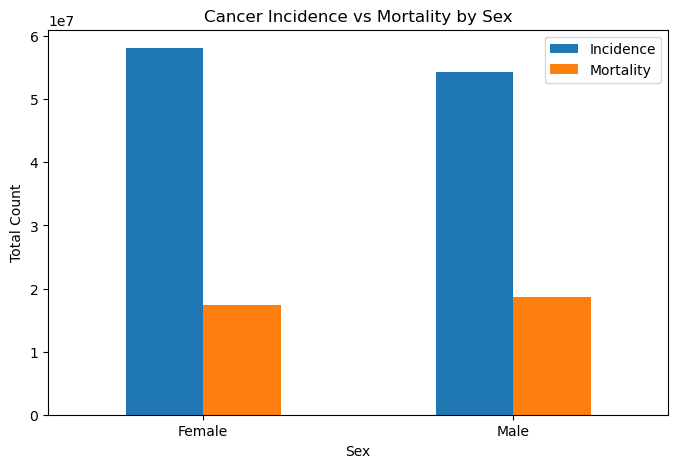

In [36]:
# Plot cancer incidence vs mortality by sex

sex_comparison_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Total Count")
plt.xlabel("Sex")
plt.title("Cancer Incidence vs Mortality by Sex")

plt.xticks(rotation=0)

plt.show()

### Interpreting Sex-Based Cancer Burden

Although females showed slightly higher overall cancer incidence counts, mortality burden between males and females appeared relatively similar.

This observation suggests that higher cancer incidence does not necessarily correspond to proportionally higher mortality burden. These differences may reflect variation in:
- cancer type distribution
- disease severity
- effectiveness of early detection
- treatment outcomes
- long-term survival across cancer types

In [37]:
# Remove combined 'All Races' summary category

clean_cancer_cdc_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["RACE"] != "All Races"
].copy()

# Verify remaining race categories

clean_cancer_cdc_df["RACE"].unique()

array(['Non-Hispanic American Indian/Alaska Native',
       'Non-Hispanic Asian/Pacific Islander', 'Non-Hispanic Black',
       'Hispanic of any race',
       'Native Hawaiinn or other Pacific Islander, Non- Hispani',
       'Non-Hispanic White'], dtype=object)

In [38]:
# Remove combined 'Male and Female' summary category

clean_cancer_cdc_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["SEX"] != "Male and Female"
].copy()
# Verify remaining sex categories

clean_cancer_cdc_df["SEX"].unique()

array(['Female', 'Male'], dtype=object)

In [39]:
clean_cancer_cdc_df

,YEAR,RACE,SEX,SITE,EVENT_TYPE,AGE_ADJUSTED_CI_LOWER,AGE_ADJUSTED_CI_UPPER,AGE_ADJUSTED_RATE,COUNT,POPULATION
11240,2018,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1224062
11241,2019,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1230918
11242,2019-2023,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,0.3,0.6,0.4,26.0,6137446
11243,2020,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1220598
11244,2021,Non-Hispanic American Indian/Alaska Native,Female,Acute Lymphocytic,Mortality,NaN,NaN,NaN,NaN,1224571
...,...,...,...,...,...,...,...,...,...,...
68394,2019-2023,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.9,8.0,7.9,52754.0,486984486
68395,2020,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.9,8.2,8.1,10430.0,97992536
68396,2021,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.9,8.2,8.1,10547.0,97570662
68397,2022,Non-Hispanic White,Male,Urinary Bladder,Mortality,7.8,8.2,8.0,10688.0,97193663


### Exporting Cleaned CDC Demographic Data
The cleaned CDC demographic cancer dataset was exported as a UTF-8 encoded CSV file for downstream PostgreSQL database integration and analytical querying workflows.

In [40]:
# Export cleaned CDC demographic dataset

clean_cancer_cdc_df.to_csv(
    "../data/cdc_demographic_data.csv",
    index=False,
    encoding="utf-8"
)

### Focusing on the Top Ten Cancer Types by Mortality Burden
To better understand the relationship between cancer burden, survival outcomes, and healthcare expenditures, the analysis was focused on the top ten cancer types associated with mortality in the United States. Prioritizing high-mortality cancers allows the project to concentrate on cancer types with the greatest public health and healthcare system impact.

This targeted approach also improves analytical consistency across CDC incidence and mortality data, SEER survival outcomes, and healthcare expenditure datasets, enabling more meaningful comparative analysis, SQL-based data integration, and downstream predictive modeling workflows.

In [41]:
# Select top cancers for deeper analysis

focus_cancers = [
    "Lung and Bronchus",
    "Pancreas",
    "Female Breast",
    "Prostate",
    "Colon and Rectum",
    "Liver and Intrahepatic Bile Duct",
    "Non-Hodgkin Lymphoma",
    "Urinary Bladder",
    "Melanomas of the Skin"
]

# Create focused cancer analysis dataframe

focus_cancer_cdc_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["SITE"].isin(focus_cancers)
].copy()

sorted(focus_cancer_cdc_df["SITE"].unique())

['Colon and Rectum',
 'Female Breast',
 'Liver and Intrahepatic Bile Duct',
 'Lung and Bronchus',
 'Melanomas of the Skin',
 'Non-Hodgkin Lymphoma',
 'Pancreas',
 'Prostate',
 'Urinary Bladder']

### Loading and Inspecting SEER Survival Data

To complement the CDC incidence and mortality dataset, survival outcome data from the SEER (Surveillance, Epidemiology, and End Results) Program was incorporated into the project workflow. The SEER dataset provides longitudinal cancer outcome statistics, including incidence rates, mortality rates, and 5-year relative survival estimates for selected major cancer types.

The purpose of integrating this dataset is to support downstream analysis of cancer outcomes and explore potential relationships between cancer burden, survival, and healthcare-related factors.

In [42]:
cancer_survival_df = pd.read_excel(
    "../data/Cancer_Survival_Data.xlsx"
)

In [43]:
cancer_survival_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Cancer_Type                        225 non-null    object 
 1   Year                               225 non-null    int64  
 2   Rate of New Cases-Observed-SEER 8  225 non-null    float64
 3   Death Rate-Observed                224 non-null    float64
 4   5-Year Relative Survival-Observed  220 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 8.9+ KB


In [44]:
cancer_survival_df

,Cancer_Type,Year,Rate of New Cases-Observed-SEER 8,Death Rate-Observed,5-Year Relative Survival-Observed
0,Lung and Bronchus,1999,62.81,55.38,0.152
1,Lung and Bronchus,2000,61.35,55.81,0.1551
2,Lung and Bronchus,2001,60.74,55.28,0.1503
3,Lung and Bronchus,2002,61.02,54.96,0.1564
4,Lung and Bronchus,2003,61.26,54.15,0.1596
...,...,...,...,...,...
220,Melanomas of the Skin,2019,28.28,2.06,-
221,Melanomas of the Skin,2020,24.14,2.06,-
222,Melanomas of the Skin,2021,27.94,2.02,-
223,Melanomas of the Skin,2022,28.64,1.98,-


In [134]:
print(cancer_survival_df.columns)

Index(['Cancer_Type', 'Year', 'incidence_rate', 'mortality_rate',
       'survival_5yr'],
      dtype='object')


In [135]:
cancer_survival_df["Cancer_Type"].unique()

array(['Lung and Bronchus', 'Pancreas', 'Female Breast', 'Prostate',
       'Colon and Rectum', 'Liver and Intrahepatic Bile Duct',
       'Non-Hodgkin Lymphoma', 'Urinary Bladder', 'Melanomas of the Skin'],
      dtype=object)

In [137]:
cancer_survival_df["Year"].agg(["min", "max"])

min    1999
max    2023
Name: Year, dtype: int64

In [138]:
# Save survival trend data for Shiny Tab 4

cancer_survival_df.to_csv(
    "../data/cancer_survival_trends.csv",
    index=False
)

In [139]:
pd.read_csv("../data/cancer_survival_trends.csv").head()

,Cancer_Type,Year,incidence_rate,mortality_rate,survival_5yr
0,Lung and Bronchus,1999,62.81,55.38,0.1520
1,Lung and Bronchus,2000,61.35,55.81,0.1551
2,Lung and Bronchus,2001,60.74,55.28,0.1503
3,Lung and Bronchus,2002,61.02,54.96,0.1564
4,Lung and Bronchus,2003,61.26,54.15,0.1596


In [140]:
survival_change = (
    cancer_survival_df
    .sort_values(["Cancer_Type", "Year"])
    .groupby("Cancer_Type")
    .agg(
        survival_1999=("survival_5yr", "first"),
        survival_2023=("survival_5yr", "last")
    )
    .reset_index()
)

survival_change["absolute_change"] = (
    survival_change["survival_2023"] - survival_change["survival_1999"]
)

survival_change["relative_change_percent"] = (
    survival_change["absolute_change"] / survival_change["survival_1999"] * 100
)

survival_change.sort_values("absolute_change", ascending=False)

,Cancer_Type,survival_1999,survival_2023,absolute_change,relative_change_percent
3,Lung and Bronchus,0.1520,0.3187,0.1667,109.671053
5,Non-Hodgkin Lymphoma,0.6331,0.7793,0.1462,23.092718
2,Liver and Intrahepatic Bile Duct,0.1078,0.2281,0.1203,111.595547
6,Pancreas,0.0529,0.1444,0.0915,172.967864
4,Melanomas of the Skin,0.9209,0.9752,0.0543,5.896406
8,Urinary Bladder,0.7776,0.8224,0.0448,5.761317
1,Female Breast,0.9002,0.9386,0.0384,4.265719
0,Colon and Rectum,0.6532,0.6773,0.0241,3.689528
7,Prostate,0.9919,0.9865,-0.0054,-0.544410


In [147]:
ratio_df = cancer_survival_df.copy()

ratio_df["mortality_incidence_ratio"] = (
    ratio_df["mortality_rate"] / ratio_df["incidence_rate"]
)

ratio_summary = (
    ratio_df
    .sort_values(["Cancer_Type", "Year"])
    .groupby("Cancer_Type")
    .agg(
        ratio_1999=("mortality_incidence_ratio", "first"),
        ratio_2023=("mortality_incidence_ratio", "last")
    )
    .reset_index()
)

ratio_summary["change"] = (
    ratio_summary["ratio_2023"] - ratio_summary["ratio_1999"]
)

ratio_summary

,Cancer_Type,ratio_1999,ratio_2023,change
0,Colon and Rectum,0.380996,0.350097,-0.030899
1,Female Breast,0.186986,0.131327,-0.055659
2,Liver and Intrahepatic Bile Duct,0.786087,0.757714,-0.028373
3,Lung and Bronchus,0.881707,0.716287,-0.165420
4,Melanomas of the Skin,0.140717,0.070064,-0.070653
5,Non-Hodgkin Lymphoma,0.417461,0.254763,-0.162698
6,Pancreas,0.987001,0.824225,-0.162776
7,Prostate,0.182812,0.146050,-0.036763
8,Urinary Bladder,0.205550,0.233314,0.027764


In [148]:
ratio_summary.to_csv(
    "../data/mortality_incidence_progress.csv",
    index=False
)

In [149]:
pd.read_csv("../data/mortality_incidence_progress.csv").head()

,Cancer_Type,ratio_1999,ratio_2023,change
0,Colon and Rectum,0.380996,0.350097,-0.030899
1,Female Breast,0.186986,0.131327,-0.055659
2,Liver and Intrahepatic Bile Duct,0.786087,0.757714,-0.028373
3,Lung and Bronchus,0.881707,0.716287,-0.165420
4,Melanomas of the Skin,0.140717,0.070064,-0.070653


In [45]:
# Replace missing survival symbols with NaN
cancer_survival_df[
    "5-Year Relative Survival-Observed"
] = cancer_survival_df[
    "5-Year Relative Survival-Observed"
].replace("-", pd.NA)

In [46]:
# Convert survival column to numeric

cancer_survival_df[
    "5-Year Relative Survival-Observed"
] = pd.to_numeric(
    cancer_survival_df[
        "5-Year Relative Survival-Observed"
    ]
)
cancer_survival_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Cancer_Type                        225 non-null    object 
 1   Year                               225 non-null    int64  
 2   Rate of New Cases-Observed-SEER 8  225 non-null    float64
 3   Death Rate-Observed                224 non-null    float64
 4   5-Year Relative Survival-Observed  180 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 8.9+ KB


### Renaming Survival Dataset Columns
The original SEER survival dataset contains long descriptive column names that can become difficult to manage during downstream analysis, SQL integration, and feature engineering. To simplify the workflow, selected columns were renamed using shorter and more analysis-friendly variable names.

In [47]:
# Rename columns for easier coding

cancer_survival_df = cancer_survival_df.rename(
    columns={
        "Rate of New Cases-Observed-SEER 8":
            "incidence_rate",

        "Death Rate-Observed":
            "mortality_rate",

        "5-Year Relative Survival-Observed":
            "survival_5yr"
    }
)

In [48]:
cancer_survival_df

,Cancer_Type,Year,incidence_rate,mortality_rate,survival_5yr
0,Lung and Bronchus,1999,62.81,55.38,0.1520
1,Lung and Bronchus,2000,61.35,55.81,0.1551
2,Lung and Bronchus,2001,60.74,55.28,0.1503
3,Lung and Bronchus,2002,61.02,54.96,0.1564
4,Lung and Bronchus,2003,61.26,54.15,0.1596
...,...,...,...,...,...
220,Melanomas of the Skin,2019,28.28,2.06,NaN
221,Melanomas of the Skin,2020,24.14,2.06,NaN
222,Melanomas of the Skin,2021,27.94,2.02,NaN
223,Melanomas of the Skin,2022,28.64,1.98,NaN


### Reshaping Top CDC Cancer Outcome Data

The CDC cancer dataset stores incidence and mortality records in a long format, where both outcomes are identified using the `EVENT_TYPE` column.

To align the CDC dataset with the SEER survival dataset, the data must be reshaped into a wide format. This transformation will create separate columns for incidence and mortality rates, making the dataset easier to compare with survival outcomes and prepare for future SQL integration.

In [49]:
# Check unique YEAR values in CDC dataset

sorted(
    focus_cancer_cdc_df["YEAR"].unique()
)

['1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2018-2022',
 '2019',
 '2019-2023',
 '2020',
 '2021',
 '2022',
 '2023']

In [50]:
# Remove grouped multi-year summary rows

cdc_yearly_df = focus_cancer_cdc_df[
    ~focus_cancer_cdc_df["YEAR"].str.contains("-")
].copy()

sorted(cdc_yearly_df['YEAR'].unique()
       )

['1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023']

In [51]:
# Reshape CDC data from long format to wide format

cdc_outcomes_df = (
    cdc_yearly_df
    .pivot_table(
        index=["SITE", "YEAR"],
        columns="EVENT_TYPE",
        values="AGE_ADJUSTED_RATE"
    )
    .reset_index()
)

cdc_outcomes_df

EVENT_TYPE,SITE,YEAR,Incidence,Mortality
0,Colon and Rectum,1999,52.59,18.940000
1,Colon and Rectum,2000,51.11,18.940000
2,Colon and Rectum,2001,51.09,18.690000
3,Colon and Rectum,2002,50.34,18.820000
4,Colon and Rectum,2003,49.99,18.040000
...,...,...,...,...
220,Urinary Bladder,2019,14.23,3.233333
221,Urinary Bladder,2020,13.04,3.170000
222,Urinary Bladder,2021,13.84,3.300000
223,Urinary Bladder,2022,12.95,3.080000


### Renaming CDC Outcome Variables
To improve consistency between the CDC and SEER datasets, selected variables were renamed using standardized epidemiological naming conventions. This step simplifies downstream SQL integration, feature engineering, and analytical modeling workflows.

In [52]:
# Rename CDC outcome columns

cdc_outcomes_df = cdc_outcomes_df.rename(
    columns={
        "SITE": "Cancer_Type",
        "YEAR": "Year",
        "Incidence": "incidence_rate",
        "Mortality": "mortality_rate"
    }
)

cdc_outcomes_df.head(3)

EVENT_TYPE,Cancer_Type,Year,incidence_rate,mortality_rate
0,Colon and Rectum,1999,52.59,18.94
1,Colon and Rectum,2000,51.11,18.94
2,Colon and Rectum,2001,51.09,18.69


In [53]:
# Convert CDC Year column to integer

cdc_outcomes_df["Year"] = (
    cdc_outcomes_df["Year"]
    .astype(int)
)

# Check datatype

cdc_outcomes_df["Year"].dtype

dtype('int64')

### Validating Epidemiological Consistency Between CDC and SEER Cancer Outcome Data

In [54]:
cdc_outcomes_df.shape

(225, 4)

In [55]:
cdc_outcomes_df.isna().sum()

EVENT_TYPE
Cancer_Type       0
Year              0
incidence_rate    9
mortality_rate    0
dtype: int64

### Interpolating Missing Incidence Rate Values
A small number of missing incidence rate observations were identified within the CDC cancer outcomes dataset. Because cancer incidence rates generally change gradually over time, linear interpolation was used to estimate missing values within each cancer type category.

In [56]:
# Interpolate missing incidence rate values by cancer type

cdc_outcomes_df["incidence_rate"] = (
    cdc_outcomes_df
    .groupby("Cancer_Type")["incidence_rate"]
    .transform(lambda x: x.interpolate())
)

In [57]:
cdc_outcomes_df.isna().sum()

EVENT_TYPE
Cancer_Type       0
Year              0
incidence_rate    0
mortality_rate    0
dtype: int64

In [58]:
# Export CDC outcomes dataset as UTF-8 encoded CSV

cdc_outcomes_df.to_csv(
    "../data/cdc_outcomes_data.csv",
    index=False,
    encoding="utf-8"
)

In [59]:
cancer_survival_df.shape

(225, 5)

In [60]:
cancer_survival_df.isna().sum()

Cancer_Type        0
Year               0
incidence_rate     0
mortality_rate     1
survival_5yr      45
dtype: int64

In [61]:
# Interpolate missing mortality rate values by cancer type

cancer_survival_df["mortality_rate"] = (
    cancer_survival_df
    .groupby("Cancer_Type")["mortality_rate"]
    .transform(lambda x: x.interpolate())
)

In [62]:
cancer_survival_df.isna().sum()

Cancer_Type        0
Year               0
incidence_rate     0
mortality_rate     0
survival_5yr      45
dtype: int64

### Exporting SEER Survival Outcome Data
The cleaned SEER survival dataset containing longitudinal incidence, mortality, and five-year relative survival outcomes was exported as a UTF-8 encoded CSV file for downstream PostgreSQL database integration and comparative cancer outcome analysis.

In [63]:
# Export SEER survival dataset as UTF-8 encoded CSV

cancer_survival_df.to_csv(
    "../data/seer_survival_data.csv",
    index=False,
    encoding="utf-8"
)

### Validating Epidemiological Consistency Between CDC and SEER Cancer Outcome Data
To evaluate compatibility between the CDC and SEER datasets, incidence and mortality rates were compared across overlapping cancer types and years. Although the datasets originate from different cancer surveillance systems with varying registry coverage, both demonstrated similar longitudinal epidemiological trends over time.

Minor differences between CDC and SEER incidence and mortality rates are expected because SEER statistics are derived from specific SEER registry populations (e.g., SEER 8 or SEER 12), whereas CDC cancer statistics reflect broader national surveillance estimates. Despite these differences, the comparable longitudinal patterns support the integration of CDC incidence and mortality outcomes with SEER survival data for downstream analytical modeling and SQL-based relational database integration.

In [64]:
# CDC lung cancer data

cdc_lung = cdc_outcomes_df[
    cdc_outcomes_df["Cancer_Type"] == "Lung and Bronchus"
]

In [65]:
# SEER lung cancer data

seer_lung = cancer_survival_df[
    cancer_survival_df["Cancer_Type"] == "Lung and Bronchus"
]

In [66]:
# Merge CDC and SEER lung data

lung_compare_df = pd.merge(
    cdc_lung,
    seer_lung,
    on=["Cancer_Type", "Year"],
    suffixes=("_cdc", "_seer")
)

In [67]:
# Verify year range in lung comparison table

lung_compare_df["Year"].min(), lung_compare_df["Year"].max()

(1999, 2023)

In [68]:
# Preview merged CDC and SEER comparison table

lung_compare_df.tail(10)

,Cancer_Type,Year,incidence_rate_cdc,mortality_rate_cdc,incidence_rate_seer,mortality_rate_seer,survival_5yr
15,Lung and Bronchus,2014,52.56,35.550000,50.75,42.65,0.2362
16,Lung and Bronchus,2015,51.90,34.430000,50.01,41.18,0.2550
17,Lung and Bronchus,2016,50.27,32.650000,49.58,39.09,0.2817
18,Lung and Bronchus,2017,50.42,31.050000,49.04,37.35,0.2954
19,Lung and Bronchus,2018,49.26,28.908333,46.93,35.51,0.3187
20,Lung and Bronchus,2019,49.07,27.950000,47.21,34.15,NaN
21,Lung and Bronchus,2020,43.04,26.991667,40.81,32.51,NaN
22,Lung and Bronchus,2021,45.26,25.741667,43.94,31.56,NaN
23,Lung and Bronchus,2022,43.12,25.833333,42.42,30.17,NaN
24,Lung and Bronchus,2023,43.12,24.608333,42.12,30.17,NaN


Minor differences between CDC and SEER incidence and mortality rates are expected because the datasets are derived from different cancer surveillance systems with varying registry coverage. In particular, SEER statistics are based on SEER registry populations (e.g., SEER 8 or SEER 12), whereas CDC cancer statistics reflect broader national surveillance estimates. Despite these differences, both datasets demonstrate comparable longitudinal epidemiological trends, supporting their combined use for integrated cancer outcome analysis.

### Loading Healthcare Cost Data

To investigate the financial burden associated with major cancer types, a healthcare expenditure dataset was incorporated into the analytical workflow. The dataset contains average per-patient annualized cancer-attributable medical care costs (reported in 2020 U.S. dollars) for medical services related to cancer care by cancer site and phase of care between 2007 and 2013.

The expenditure variables include:
- Initial care costs
- Continuing care costs
- Last year of life costs

These healthcare cost estimates will later be integrated with CDC incidence and mortality outcomes and SEER survival data to support comparative cancer outcome analysis, SQL-based data integration, and downstream predictive modeling workflows.

In [69]:
# Load cancer cost dataset

cancer_cost_df = pd.read_csv(
    "../data/Cancer_Cost_Data.csv",
    encoding="utf-8"
)

In [70]:
cancer_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancer_Type        9 non-null      object 
 1   Initial_Care       9 non-null      float64
 2   Continuing_Care    9 non-null      float64
 3   Last_Year_of_Life  9 non-null      float64
dtypes: float64(3), object(1)
memory usage: 420.0+ bytes


### Converting Healthcare Cost Variables to Numeric Format
The healthcare expenditure variables were initially imported as text objects because the original dataset contained currency formatting symbols and comma separators. These variables must be converted into numeric format to support downstream statistical analysis, SQL integration, and machine learning workflows.

In [71]:
# Define healthcare cost columns

cost_columns = [
    "Initial_Care",
    "Continuing_Care",
    "Last_Year_of_Life"
]

In [72]:
# Convert healthcare cost variables to numeric format

for col in cost_columns:

    cancer_cost_df[col] = pd.to_numeric(
        cancer_cost_df[col]
        .replace(r"[\$,]", "", regex=True),
        errors="coerce"
    )

In [73]:
cancer_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancer_Type        9 non-null      object 
 1   Initial_Care       9 non-null      float64
 2   Continuing_Care    9 non-null      float64
 3   Last_Year_of_Life  9 non-null      float64
dtypes: float64(3), object(1)
memory usage: 420.0+ bytes


### Exporting Healthcare Cost Data
The cleaned healthcare expenditure dataset containing annualized cancer-attributable medical care costs by phase of care was exported as a UTF-8 encoded CSV file for downstream PostgreSQL database integration and comparative healthcare burden analysis.

In [74]:
# Export healthcare cost dataset as UTF-8 encoded CSV

cancer_cost_df.to_csv(
    "../data/cancer_cost_data.csv",
    index=False,
    encoding="utf-8"
)

### Preparing Cleaned Analytical Tables for PostgreSQL Integration

The cleaned CDC, SEER, and healthcare expenditure datasets were exported as UTF-8 encoded CSV files for downstream PostgreSQL database integration. These relational tables will support SQL-based joins, analytical querying workflows, and downstream predictive modeling.

In [75]:
# CMS metadata API endpoint
url = "https://data.cms.gov/provider-data/api/1/metastore/schemas/dataset/items/z8ax-x9j1"

# Send request to CMS API
response = requests.get(url)

# Check request status
response.status_code

200

In [76]:
# Convert API response into Python dictionary
cms_metadata = response.json()

In [77]:
# View main keys in the JSON data
cms_metadata.keys()

dict_keys(['accessLevel', 'landingPage', 'bureauCode', 'issued', '@type', 'modified', 'released', 'keyword', 'contactPoint', 'publisher', 'identifier', 'description', 'title', 'programCode', 'distribution', 'theme'])

In [78]:
# View dataset title
cms_metadata.get("title")

'Complications and Unplanned Hospital Visits - PPS-Exempt Cancer Hospital - Hospital'

In [79]:
# View dataset description
cms_metadata.get("description")

'Prospective Payment System (PPS)-Exempt Cancer Hospital Quality Reporting (PCHQR) Complications and Unplanned Hospital Visits. This dataset includes the percentage of patients who are receiving PCH-based outpatient chemotherapy treatment for all cancer types except leukemia who were admitted to the hospital or visited the emergency department for one of 10 conditions within 30 days after treatment. The dataset also includes the rate at which cancer patients have unplanned readmissions within 30 days of discharge from an eligible index admission. Finally, the dataset also includes the analysis of complications of a prostatectomy by comparing outcomes at the hospital/facility level during the year after prostate-directed surgery.'

In [80]:
# Pretty-print first part of the JSON
print(json.dumps(cms_metadata, indent=2)[:3000])

{
  "accessLevel": "public",
  "landingPage": "https://data.cms.gov/provider-data/dataset/z8ax-x9j1",
  "bureauCode": [
    "009:38"
  ],
  "issued": "2024-07-31",
  "@type": "dcat:Dataset",
  "modified": "2026-04-21",
  "released": "2026-05-13",
  "keyword": [
    "Cancer",
    "Readmissions",
    "Emergency Department",
    "PPS-Exempt Cancer Hospital Quality Reporting",
    "Complications"
  ],
  "contactPoint": {
    "@type": "vcard:Contact",
    "fn": "Hospital Compare",
    "hasURL": "https://cmsqualitysupport.servicenowservices.com/qnet_qa"
  },
  "publisher": {
    "@type": "org:Organization",
    "name": "Centers for Medicare & Medicaid Services (CMS)"
  },
  "identifier": "z8ax-x9j1",
  "description": "Prospective Payment System (PPS)-Exempt Cancer Hospital Quality Reporting (PCHQR) Complications and Unplanned Hospital Visits. This dataset includes the percentage of patients who are receiving PCH-based outpatient chemotherapy treatment for all cancer types except leukemia who

In [81]:
# Check distribution/download/API resources
cms_metadata.get("distribution")

[{'@type': 'dcat:Distribution',
  'downloadURL': 'https://data.cms.gov/provider-data/sites/default/files/resources/bc386a698d7a9b8d09bf37a73371a899_1776974804/PCH_Complications_Unplanned_Hospital_Visits_HOSPITAL.csv',
  'mediaType': 'text/csv',
  'describedBy': 'https://data.cms.gov/provider-data/sites/default/files/data_dictionaries/hospital/HOSPITAL_Data_Dictionary.pdf',
  'describedByType': 'application/pdf'}]

In [82]:
# Convert distribution section to dataframe for easier viewing
distribution_df = pd.DataFrame(cms_metadata.get("distribution"))

# Display distribution dataframe
distribution_df.head()

,@type,downloadURL,mediaType,describedBy,describedByType
0,dcat:Distribution,https://data.cms.gov/provider-data/sites/defau...,text/csv,https://data.cms.gov/provider-data/sites/defau...,application/pdf


# Load Integrated Cancer Summary Dataset

After integrating CDC incidence and mortality data, SEER five-year survival data, and cancer treatment cost data in SQL, the final summary table was exported as a CSV file. This dataset contains key epidemiological, survival, economic, and diagnosis challenge metrics for nine major cancer types and serves as the foundation for the visualization and correlation analyses performed in Python.

In [111]:
# Load CSV file
cancer_burden_df = pd.read_csv("../data/master_cancer_summary.csv")
cancer_burden_df

,cancer_type,diagnosis_challenge,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life
0,Pancreas,High,12.06,9.97,0.09,0.83,108166,18427,125031
1,Liver and Intrahepatic Bile Duct,High,11.06,8.33,0.19,0.75,62776,18219,92134
2,Lung and Bronchus,Moderate-High,53.77,37.13,0.21,0.69,68293,12389,110248
3,Colon and Rectum,Moderate,43.11,15.47,0.67,0.36,66524,6246,110144
4,Non-Hodgkin Lymphoma,Moderate,16.39,5.07,0.73,0.31,75164,12805,144707
5,Urinary Bladder,Moderate,14.81,3.43,0.80,0.23,26443,6350,95985
6,Prostate,Low,127.66,23.34,0.99,0.18,28109,2603,74227
7,Female Breast,Low,110.44,19.30,0.92,0.17,34980,3540,76101
8,Melanomas of the Skin,Low,8.53,1.24,0.95,0.15,8537,2707,78912


In [112]:
cancer_burden_df.shape

(9, 9)

In [114]:
cancer_burden_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cancer_type          9 non-null      object 
 1   diagnosis_challenge  9 non-null      object 
 2   incidence            9 non-null      float64
 3   mortality            9 non-null      float64
 4   survival             9 non-null      float64
 5   mortality_ratio      9 non-null      float64
 6   initial_care         9 non-null      int64  
 7   continuing_care      9 non-null      int64  
 8   last_year_of_life    9 non-null      int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 780.0+ bytes


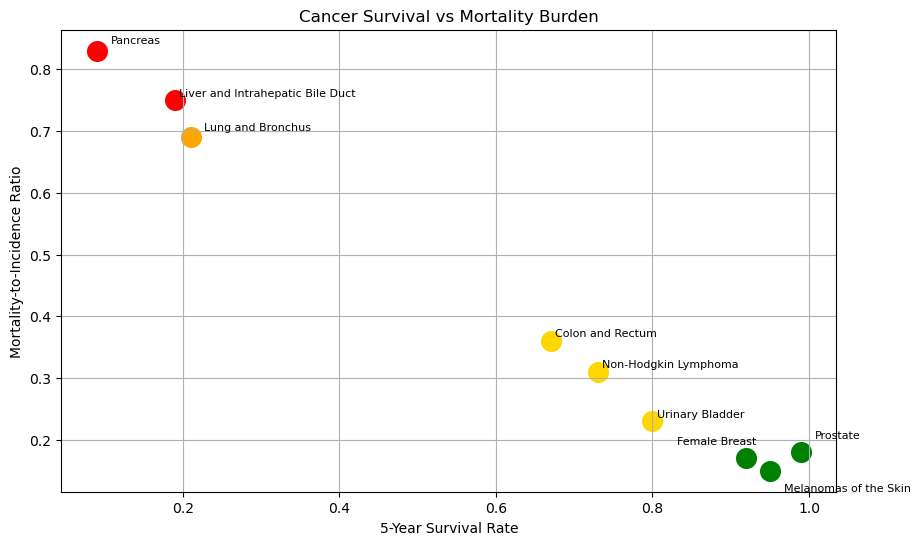

In [115]:
plt.figure(figsize=(10, 6))

colors = {
    "High": "red",
    "Moderate-High": "orange",
    "Moderate": "gold",
    "Low": "green"
}

offsets = {
    "Pancreas": (10, 5),
    "Liver and Intrahepatic Bile Duct ": (15, 5),
    "Lung and Bronchus": (10, 5),
    "Prostate": (10, 10),
    "Female Breast": (-50, 10),
    "Melanomas of the Skin": (10, -15),
    
}

for _, row in df.iterrows():

    plt.scatter(
        row["survival"],
        row["mortality_ratio"],
        s=200,
        color=colors[row["diagnosis_challenge"]]
    )

    dx, dy = offsets.get(
        row["cancer_type"],
        (3, 3)
    )

    plt.annotate(
        row["cancer_type"],
        (row["survival"], row["mortality_ratio"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("5-Year Survival Rate")
plt.ylabel("Mortality-to-Incidence Ratio")
plt.title("Cancer Survival vs Mortality Burden")

plt.grid(True)

plt.show()

### Cancer Survival vs Mortality Burden

This visualization examines the relationship between 5-year survival rates and mortality burden across cancer types. Mortality burden is represented by the mortality-to-incidence ratio, which provides a measure of how deadly a cancer is relative to how frequently it occurs.

An inverse relationship is expected, where cancers with higher mortality burden tend to have lower survival rates. For example, pancreatic, liver, and lung cancers show high mortality burden and poor survival outcomes, while prostate, breast, and melanoma cancers generally have lower mortality burden and higher survival rates.

This analysis helps identify cancers that remain particularly challenging to diagnose and treat, highlighting areas where improved detection, treatment, and healthcare resources may have the greatest impact.

In [116]:
# Correlation Between Survival and Mortality Burden
correlation = cancer_burden_df['survival'].corr(cancer_burden_df['mortality_ratio'])

print(f"Correlation: {correlation:.3f}")

Correlation: -0.995


## Interpretation

A Pearson correlation coefficient of -0.995 indicates an extremely strong negative relationship between survival rate and mortality burden.

This suggests that cancers with lower five-year survival rates tend to exhibit substantially higher mortality burden ratios, while cancers with higher survival rates generally exhibit lower mortality burden.

The result provides strong quantitative support for the patterns observed in the visualization and validates the mortality burden metric using independent survival outcome data.

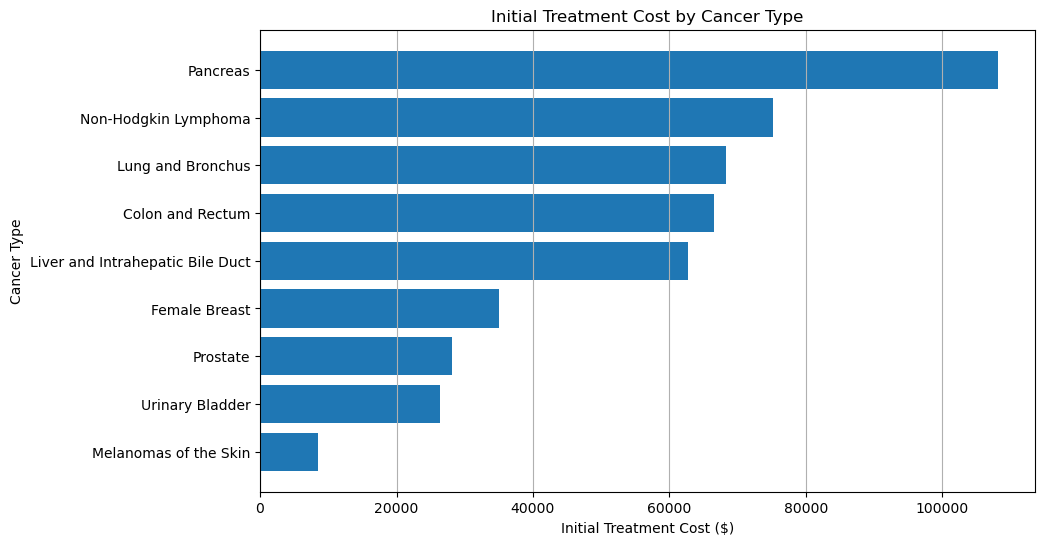

In [117]:
# Initial Treatment Cost by Cancer Type
# Sort by initial care cost
cost_df = cancer_burden_df.sort_values("initial_care", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    cost_df["cancer_type"],
    cost_df["initial_care"]
)

plt.xlabel("Initial Treatment Cost ($)")
plt.ylabel("Cancer Type")
plt.title("Initial Treatment Cost by Cancer Type")

plt.grid(axis="x")

plt.show()

## Interpretation

Initial treatment costs vary substantially across cancer types. Pancreatic cancer exhibited the highest average initial treatment cost, while melanoma showed the lowest. Several cancers associated with poor survival outcomes, including pancreatic, lung, and liver cancer, also demonstrated relatively high treatment costs, highlighting the combined clinical and economic burden imposed by these diseases.

In [118]:
# Five-Year Survival Improvement (1999–2023)
survival_df = pd.DataFrame({
    "cancer_type": [
        "Colon and Rectum",
        "Female Breast",
        "Liver and Intrahepatic Bile Duct",
        "Lung and Bronchus",
        "Melanomas of the Skin",
        "Non-Hodgkin Lymphoma",
        "Pancreas",
        "Prostate",
        "Urinary Bladder"
    ],
    "early_survival": [0.66, 0.90, 0.12, 0.15, 0.92, 0.65, 0.05, 0.99, 0.80],
    "recent_survival": [0.68, 0.94, 0.23, 0.32, 0.98, 0.78, 0.14, 0.99, 0.82]
})

survival_df["improvement"] = (
    survival_df["recent_survival"]
    - survival_df["early_survival"]
)

survival_df = survival_df.sort_values(
    "improvement",
    ascending=True
)

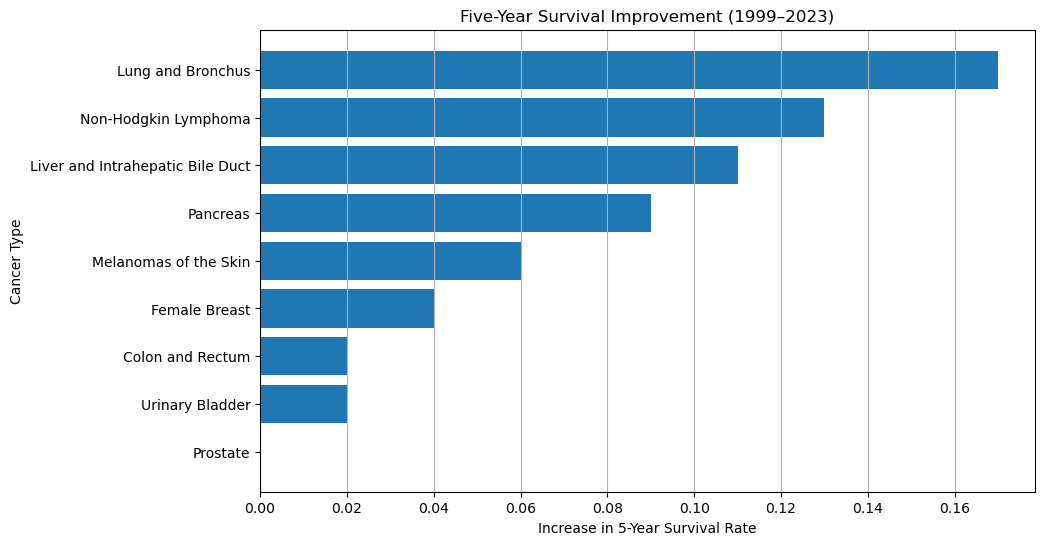

In [119]:
plt.figure(figsize=(10, 6))

plt.barh(
    survival_df["cancer_type"],
    survival_df["improvement"]
)

plt.xlabel("Increase in 5-Year Survival Rate")
plt.ylabel("Cancer Type")
plt.title("Five-Year Survival Improvement (1999–2023)")

plt.grid(axis="x")

plt.show()

This visualization compares the change in 5-year survival rates between 1999 and 2023 for each cancer type. It highlights which cancers have shown the

In [121]:
import pandas as pd

cancer_re_insights_df = pd.read_csv("../data/cancer_research_insights")

cancer_re_insights_df.head(3)

,cancer_type,diagnosis_challenge,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life,insight_1,insight_2,insight_3,insight_4
0,Pancreas,High,12.06,9.97,0.09,0.83,108166,18427,125031,Deep anatomical location makes early detection...,Few or no symptoms in early stages,Symptoms can mimic less serious digestive cond...,No routine screening test for the general popu...
1,Liver and Intrahepatic Bile Duct,High,11.06,8.33,0.19,0.75,62776,18219,92134,Often diagnosed at later stages,Underlying liver disease such as cirrhosis or ...,Treatment options become limited when advanced,Higher risk of recurrence
2,Lung and Bronchus,Moderate-High,53.77,37.13,0.21,0.69,68293,12389,110248,Often detected at later stages,Aggressive tumor biology contributes to rapid ...,Curative treatment options are limited once ad...,High incidence contributes to large mortality ...


In [122]:
cancer_re_insights_df.shape

(9, 13)

In [123]:
cancer_re_insights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cancer_type          9 non-null      object 
 1   diagnosis_challenge  9 non-null      object 
 2   incidence            9 non-null      float64
 3   mortality            9 non-null      float64
 4   survival             9 non-null      float64
 5   mortality_ratio      9 non-null      float64
 6   initial_care         9 non-null      int64  
 7   continuing_care      9 non-null      int64  
 8   last_year_of_life    9 non-null      int64  
 9   insight_1            9 non-null      object 
 10  insight_2            9 non-null      object 
 11  insight_3            9 non-null      object 
 12  insight_4            9 non-null      object 
dtypes: float64(4), int64(3), object(6)
memory usage: 1.0+ KB


In [124]:
cancer_re_insights_df.sort_values(
    "mortality_ratio",
    ascending=False
)[
    ["cancer_type",
     "mortality_ratio",
     "survival"]
]

,cancer_type,mortality_ratio,survival
0,Pancreas,0.83,0.09
1,Liver and Intrahepatic Bile Duct,0.75,0.19
2,Lung and Bronchus,0.69,0.21
3,Colon and Rectum,0.36,0.67
4,Non-Hodgkin Lymphoma,0.31,0.73
5,Urinary Bladder,0.23,0.80
6,Prostate,0.18,0.99
7,Female Breast,0.17,0.92
8,Melanomas of the Skin,0.15,0.95


In [125]:
# Add ML cluster labels for Shiny dashboard

cancer_re_insights_df["ml_cluster"] = [
    "High Burden Cluster",
    "High Burden Cluster",
    "High Burden Cluster",
    "Moderate Burden Cluster",
    "Moderate Burden Cluster",
    "Moderate Burden Cluster",
    "Lower Burden Cluster",
    "Lower Burden Cluster",
    "Moderate Burden Cluster"
]

In [126]:
# Verify ML cluster column

cancer_re_insights_df[
    ["cancer_type", "diagnosis_challenge", "ml_cluster"]
]

,cancer_type,diagnosis_challenge,ml_cluster
0,Pancreas,High,High Burden Cluster
1,Liver and Intrahepatic Bile Duct,High,High Burden Cluster
2,Lung and Bronchus,Moderate-High,High Burden Cluster
3,Colon and Rectum,Moderate,Moderate Burden Cluster
4,Non-Hodgkin Lymphoma,Moderate,Moderate Burden Cluster
5,Urinary Bladder,Moderate,Moderate Burden Cluster
6,Prostate,Low,Lower Burden Cluster
7,Female Breast,Low,Lower Burden Cluster
8,Melanomas of the Skin,Low,Moderate Burden Cluster


In [129]:
cancer_re_insights_df.to_csv(
    "../data/cancer_research_insights_v2.csv",
    index=False
)

In [128]:
cancer_re_insights_df.columns

Index(['cancer_type', 'diagnosis_challenge', 'incidence', 'mortality',
       'survival', 'mortality_ratio', 'initial_care', 'continuing_care',
       'last_year_of_life', 'insight_1', 'insight_2', 'insight_3', 'insight_4',
       'ml_cluster'],
      dtype='object')

In [130]:
cancer_re_insights_df.head(3)

,cancer_type,diagnosis_challenge,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life,insight_1,insight_2,insight_3,insight_4,ml_cluster
0,Pancreas,High,12.06,9.97,0.09,0.83,108166,18427,125031,Deep anatomical location makes early detection...,Few or no symptoms in early stages,Symptoms can mimic less serious digestive cond...,No routine screening test for the general popu...,High Burden Cluster
1,Liver and Intrahepatic Bile Duct,High,11.06,8.33,0.19,0.75,62776,18219,92134,Often diagnosed at later stages,Underlying liver disease such as cirrhosis or ...,Treatment options become limited when advanced,Higher risk of recurrence,High Burden Cluster
2,Lung and Bronchus,Moderate-High,53.77,37.13,0.21,0.69,68293,12389,110248,Often detected at later stages,Aggressive tumor biology contributes to rapid ...,Curative treatment options are limited once ad...,High incidence contributes to large mortality ...,High Burden Cluster


## Load Cancer RAG Knowledge Corpus

The first step in building the Cancer Intelligence Assistant is loading the source documents that will serve as the knowledge base for the Retrieval-Augmented Generation (RAG) pipeline. The corpus consists of nine cancer-specific documents and two supporting literature reports covering cancer statistics and economic burden. These documents provide scientific context on disease burden, risk factors, diagnosis challenges, screening, treatment options, prevention strategies, and future opportunities. Once loaded, the documents will be prepared for chunking, embedding generation, vector indexing, and semantic retrieval.

In [153]:
from pathlib import Path

rag_path = Path("../data/RAG_files")

files = list(rag_path.glob("*"))

print(f"Number of files: {len(files)}")

for file in files:
    print(file.name)

Number of files: 11
2025-cancer-facts-and-figures-acs.pdf
Annual_Report_Cancer_Patient_Economic_Burden.pdf
Colon cancer.docx
Female Breast Cancer.docx
Liver Cancer.docx
Lung Cancer.docx
Melanoma of skin cancer.docx
Non-Hodgkin Lymphoma cancer.docx
Pancreatic Cancer.docx
Prostate Cancer.docx
Urinary Bladder cancer.docx


In [155]:
from docx import Document
rag_path = Path("../data/RAG_files")

docx_files = list(rag_path.glob("*.docx"))

docx_texts = []

for file in docx_files:
    doc = Document(file)
    text = "\n".join([p.text for p in doc.paragraphs])
    
    docx_texts.append({
        "file_name": file.name,
        "text": text
    })

print(f"Loaded DOCX files: {len(docx_texts)}")

for item in docx_texts:
    print(item["file_name"], ":", len(item["text"]), "characters")

Loaded DOCX files: 9
Colon cancer.docx : 3955 characters
Female Breast Cancer.docx : 11677 characters
Liver Cancer.docx : 23629 characters
Lung Cancer.docx : 7345 characters
Melanoma of skin cancer.docx : 13762 characters
Non-Hodgkin Lymphoma cancer.docx : 22970 characters
Pancreatic Cancer.docx : 7793 characters
Prostate Cancer.docx : 12509 characters
Urinary Bladder cancer.docx : 5977 characters


In [156]:
from langchain_community.document_loaders import PyPDFLoader

C:\Users\dhans\AppData\Local\Temp\ipykernel_25780\4175148793.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [157]:
print("PyPDFLoader imported successfully!")

PyPDFLoader imported successfully!


In [163]:
pdf_loader = PyPDFLoader(
    "../data/RAG_files/2025-cancer-facts-and-figures-acs.pdf"
)

pdf_docs_1 = pdf_loader.load()

print(f"Pages loaded: {len(pdf_docs_1)}")

Pages loaded: 48


In [164]:
pdf_loader = PyPDFLoader(
    "../data/RAG_files/Annual_Report_Cancer_Patient_Economic_Burden.pdf"
)

pdf_docs_2 = pdf_loader.load()

print(f"Pages loaded: {len(pdf_docs_2)}")

Pages loaded: 13


In [165]:
print("DOCX files:", len(docx_texts))
print("ACS PDF pages:", len(pdf_docs_1))
print("Economic PDF pages:", len(pdf_docs_2))

DOCX files: 9
ACS PDF pages: 48
Economic PDF pages: 13


## Document Loading Complete

The Cancer RAG knowledge corpus was successfully loaded into memory. The corpus includes nine cancer-specific documents and two supporting literature reports. Together, these sources provide information on cancer burden, survival, risk factors, diagnosis challenges, screening, treatment strategies, prevention opportunities, and economic impact. This knowledge base will be used to build the retrieval system for the Cancer Intelligence Assistant.

In [166]:
{
    "file_name": "...",
    "text": "..."
}

{'file_name': '...', 'text': '...'}

## Create LangChain Documents

After loading the cancer knowledge corpus, the documents are converted into LangChain Document objects. These objects store the document text along with metadata such as the source file name, allowing the retrieval system to track where information originates. The resulting collection will be used for document chunking and semantic search.

In [167]:
from langchain_core.documents import Document

documents = []

for item in docx_texts:

    doc = Document(
        page_content=item["text"],
        metadata={
            "source": item["file_name"]
        }
    )

    documents.append(doc)

print(f"Number of LangChain documents: {len(documents)}")

Number of LangChain documents: 9


In [168]:
print(documents[0].metadata)
print(documents[0].page_content[:500])

{'source': 'Colon cancer.docx'}
Incidence and Mortality
Worldwide, colorectal cancer is the third most common form of cancer. In 2022, there were an estimated 1.93 million new cases of colorectal cancer and 903,859 deaths.[1]
Estimated new cases and deaths from colon and rectal cancer in the United States in 2025:[2]
New cases of colon cancer: 107,320.
New cases of rectal cancer: 46,950.
Deaths: 52,900 (colon and rectal cancers combined).
Gastrointestinal stromal tumors can occur in the colon. For more information, see Gastroi


In [169]:
print(pdf_docs_1[0].metadata)
print(pdf_docs_1[0].page_content[:500])

{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-02-19T09:30:41-07:00', 'moddate': '2025-02-19T09:31:10-07:00', 'title': 'Cancer Facts & Figures 2025', 'trapped': '/False', 'source': '../data/RAG_files/2025-cancer-facts-and-figures-acs.pdf', 'total_pages': 48, 'page': 0, 'page_label': 'a'}
AL
30,030
AZ
42,560 AR
19,700
CA
199,980
CO
29,020
CT 23,920
DE 7,680
FL
171,960
GA
66,210
ID
11,820
IL
78,870
IN
42,150
IA
21,340
KS
15,810 KY
30,420
LA
29,980
ME
11,080
MD 37,200
MA
44,000
MN
37,650
MS
17,820
MO
39,220
MT
7,560
NE
12,390
NV
17,540
NH
10,290
NJ 59,840
NM
11,540
NY
123,430
NC
71,320
ND
4,510
OH
77,010
OK
24,120
OR
26,980
PA
90,240
RI 7,480
SC
35,300
SD
5,870
TN
42,750
TX
150,870
UT
14,120
VT
4,670
VA
50,510
WA
46,500
WV
13,250
WI
39,940WY
3,580
DC 3,140
HI
9,040
AK
3,670
MI
66,0


In [170]:
documents.extend(pdf_docs_1)
documents.extend(pdf_docs_2)

print(len(documents))

70


In [171]:
print(documents[20].metadata)
print(documents[20].page_content[:500])

{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-02-19T09:30:41-07:00', 'moddate': '2025-02-19T09:31:10-07:00', 'title': 'Cancer Facts & Figures 2025', 'trapped': '/False', 'source': '../data/RAG_files/2025-cancer-facts-and-figures-acs.pdf', 'total_pages': 48, 'page': 11, 'page_label': '10'}
10   Cancer Facts & Figures 2025
late in life); not having children or having a first child 
after age 30; high natural levels of estrogen or 
testosterone; and recent use of hormonal contraceptives. 
Prevention: In addition to reducing risk through 
previously mentioned lifestyle choices, some women at 
high risk because of a strong family history or 
inherited genetic mutations may consider medicines 
(e.g., tamoxifen) or surgery (prophylactic mastectomy, 
or removal of the breasts). Women tak


## Document Chunking

Large documents are divided into smaller overlapping text chunks before generating embeddings. Chunking helps the retrieval system identify and return the most relevant sections of text in response to a user query, while preserving sufficient context for accurate question answering.

In [173]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [176]:
# Split documents into smaller chunks for RAG retrieval

chunks = text_splitter.split_documents(documents)

print(f"Original documents: {len(documents)}")
print(f"Total chunks: {len(chunks)}")

Original documents: 70
Total chunks: 483


## Document Chunking

The combined cancer knowledge corpus was divided into smaller overlapping text chunks using a Recursive Character Text Splitter. Chunking improves retrieval performance by allowing the vector database to search for relevant sections of text rather than entire documents. A chunk size of 1,000 characters with a 200-character overlap was used to preserve context between neighboring chunks.

Results:
- Original Documents: 70
- Total Chunks: 483

In [178]:
print(chunks[100].metadata)
print(chunks[100].page_content[:1000])

{'source': 'Non-Hodgkin Lymphoma cancer.docx'}
Burkitt lymphoma. Burkitt lymphoma is a type of B-cell non-Hodgkin lymphoma that grows and spreads very quickly. It may affect the jaw, bones of the face, bowel, kidneys, ovaries, or other organs. There are three main types of Burkitt lymphoma (endemic, sporadic, and immunodeficiency related). Endemic Burkitt lymphoma commonly occurs in Africa and is linked to the Epstein-Barr virus, and sporadic Burkitt lymphoma occurs throughout the world. Immunodeficiency-related Burkitt lymphoma is most often seen in patients who have AIDS. Burkitt lymphoma may spread to the brain and spinal cord and treatment to prevent its spread may be given. Burkitt lymphoma occurs most often in children and young adults. For more information, see Childhood Non-Hodgkin Lymphoma Treatment. Burkitt lymphoma is also called diffuse small noncleaved-cell lymphoma.


In [183]:
for i, chunk in enumerate(chunks):
    print(i, chunk.metadata["source"])
    
    if ".pdf" in chunk.metadata["source"]:
        print("First PDF chunk index:", i)
        print(chunk.metadata)
        print(chunk.page_content[:500])
        break
    
    if ".pdf" in chunk.metadata["source"]:
        print("First PDF chunk index:", i)
        print(chunk.metadata)
        print(chunk.page_content[:500])
        break

0 Colon cancer.docx
1 Colon cancer.docx
2 Colon cancer.docx
3 Colon cancer.docx
4 Colon cancer.docx
5 Female Breast Cancer.docx
6 Female Breast Cancer.docx
7 Female Breast Cancer.docx
8 Female Breast Cancer.docx
9 Female Breast Cancer.docx
10 Female Breast Cancer.docx
11 Female Breast Cancer.docx
12 Female Breast Cancer.docx
13 Female Breast Cancer.docx
14 Female Breast Cancer.docx
15 Female Breast Cancer.docx
16 Female Breast Cancer.docx
17 Female Breast Cancer.docx
18 Female Breast Cancer.docx
19 Female Breast Cancer.docx
20 Female Breast Cancer.docx
21 Liver Cancer.docx
22 Liver Cancer.docx
23 Liver Cancer.docx
24 Liver Cancer.docx
25 Liver Cancer.docx
26 Liver Cancer.docx
27 Liver Cancer.docx
28 Liver Cancer.docx
29 Liver Cancer.docx
30 Liver Cancer.docx
31 Liver Cancer.docx
32 Liver Cancer.docx
33 Liver Cancer.docx
34 Liver Cancer.docx
35 Liver Cancer.docx
36 Liver Cancer.docx
37 Liver Cancer.docx
38 Liver Cancer.docx
39 Liver Cancer.docx
40 Liver Cancer.docx
41 Liver Cancer.docx


## Chunk Verification

The document chunking step successfully divided the combined cancer knowledge corpus into smaller text segments. The first 150 chunks came from the cancer-specific DOCX files, and the PDF report chunks begin at index 150. Metadata was preserved during chunking, allowing each chunk to retain its original source document and page information when available.

In [185]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [186]:
test_vector = embeddings.embed_query(
    "Why is pancreatic cancer difficult to diagnose?"
)

print(type(test_vector))
print(len(test_vector))

<class 'list'>
384


## Embedding Model Verification

The embedding model was successfully loaded and tested using a sample query. The model converts text into 384-dimensional numerical vectors that capture semantic meaning. These vector representations allow the retrieval system to identify similar concepts and retrieve relevant cancer knowledge based on user questions.

In [188]:
from langchain_community.vectorstores import FAISS
# Build FAISS vector database from document chunks

vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print("FAISS vector store created successfully!")


FAISS vector store created successfully!


In [189]:
# Create retriever from FAISS vector store

retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 4
    }
)

print("Retriever created successfully!")

Retriever created successfully!


## Final Conclusions

This project integrated CDC incidence and mortality data, SEER survival data, healthcare cost estimates, research-derived cancer insights, and machine learning techniques into a unified cancer burden analysis framework.

The analysis identified a strong inverse relationship between mortality-to-incidence ratio and five-year survival across major cancer types. Pancreatic, liver, and lung cancers exhibited the highest mortality burden and lowest survival outcomes, while prostate, female breast, and melanoma cancers demonstrated the most favorable survival rates.

To better understand these patterns, research insights derived from authoritative cancer information sources were incorporated into the analysis. These findings consistently suggested that cancers with poor outcomes are often associated with delayed diagnosis, limited screening opportunities, aggressive disease progression, and reduced treatment windows. In contrast, cancers with favorable outcomes are frequently linked to early detection, established screening programs, visible symptoms, and effective treatment options.

To further validate these findings, a hierarchical clustering model was applied using incidence, mortality, survival, mortality-to-incidence ratio, and healthcare cost measures. Without using the manually assigned burden categories, the machine learning algorithm naturally grouped pancreatic, liver, and lung cancers into a high-burden cluster and prostate and female breast cancers into a lower-burden cluster. These results closely aligned with the burden patterns identified through descriptive analysis and provided independent validation of the cancer burden framework developed throughout the project.

The integration of structured healthcare data, research-derived insights, retrieval-augmented AI methods, and machine learning provided a more comprehensive understanding of cancer burden than descriptive statistics alone. This multidisciplinary approach demonstrates how analytics, artificial intelligence, and unsupervised learning techniques can be combined to explain observed healthcare patterns and support evidence-based interpretation of cancer outcomes.

Overall, the findings suggest that early detection, screening availability, treatment effectiveness, and timely diagnosis are among the most important factors associated with improved cancer survival outcomes. The machine learning results further reinforce the conclusion that cancers with similar clinical and economic burden characteristics naturally group together, supporting the use of integrated data-driven approaches for understanding and communicating cancer burden.